In [1]:
import os
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
os.environ["SLURM_TIME_FORMAT"] = "%s"

In [3]:
def get_data_from_sacct(clusters: str,
                        partition: str,
                        start_date: str,
                        end_date: str,
                        fields: str) -> pd.DataFrame:
    """Return a dataframe of the sacct output."""
    cmd = f"sacct -M {clusters} -a -X -P -n -S {start_date} -E {end_date} -o {fields}"
    if partition:
        cmd += f" -r {partition}"
    output = subprocess.run(cmd,
                            stdout=subprocess.PIPE,
                            shell=True,
                            timeout=100,
                            text=True,
                            check=True)
    rows = output.stdout.strip().split('\n')
    cols = fields.split(",")
    raw = pd.DataFrame([row.split("|")[:len(cols)]
                       for row in rows if row.count("|") > len(cols) - 2])
    raw.columns = cols
    return raw

In [4]:
def clean_dataframe(df: pd.DataFrame):
    """Clean the dataframe and set data types."""
    for col in ["elapsedraw", "start", "end", "ncpus"]:
        df = df[pd.notna(df[col])]
        df = df[df[col].str.isnumeric()]
        df[col] = df[col].astype("int64")
    df = df[df.elapsedraw > 0]
    return df

In [5]:
if __name__ == "__main__":

    clusters = "adroit"
    partition = "class"
    start_date = "2025-09-01T00:00:00"
    end_date   = "now"
    fields = "elapsedraw,start,end,ncpus,state"

    df = get_data_from_sacct(clusters, partition, start_date, end_date, fields)
    df = df[(df.state != "RUNNING") | (df.state != "PENDING")]
    df = clean_dataframe(df)
    df = df[(df.start > 1_000_000_000) & (df.end > 1_000_000_000)]
    df = df[df.start <= df.end]

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 32531 entries, 0 to 34554
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   elapsedraw  32531 non-null  int64
 1   start       32531 non-null  int64
 2   end         32531 non-null  int64
 3   ncpus       32531 non-null  int64
 4   state       32531 non-null  str  
dtypes: int64(4), str(1)
memory usage: 1.8 MB


In [7]:
df.describe()

,elapsedraw,start,end,ncpus
count,32531.000000,3.253100e+04,3.253100e+04,32531.00000
mean,8432.387569,1.768717e+09,1.768726e+09,5.75654
std,21337.301577,8.230878e+06,8.228297e+06,8.09917
min,1.000000,1.756787e+09,1.756836e+09,1.00000
25%,224.500000,1.761524e+09,1.761530e+09,1.00000
50%,3629.000000,1.770133e+09,1.770137e+09,2.00000
75%,10809.000000,1.773898e+09,1.773898e+09,4.00000
max,432029.000000,1.790834e+09,1.790857e+09,64.00000


In [8]:
minutes = 5
seconds_per_minute = 60
sampling_period_seconds = minutes * seconds_per_minute

In [9]:
samples = (df.end.max() - df.start.min()) // sampling_period_seconds
samples = samples.item()
samples

113567

In [10]:
cores = []
times = []
for i in range(samples):
    t = df.start.min() + i * sampling_period_seconds
    allocated_cores = df[(df.start <= t) & (df.end >= t)].ncpus.sum()
    cores.append(allocated_cores)
    times.append(t)

In [11]:
cores_max = 9 * 32 + 128 + 96
cores_max

512

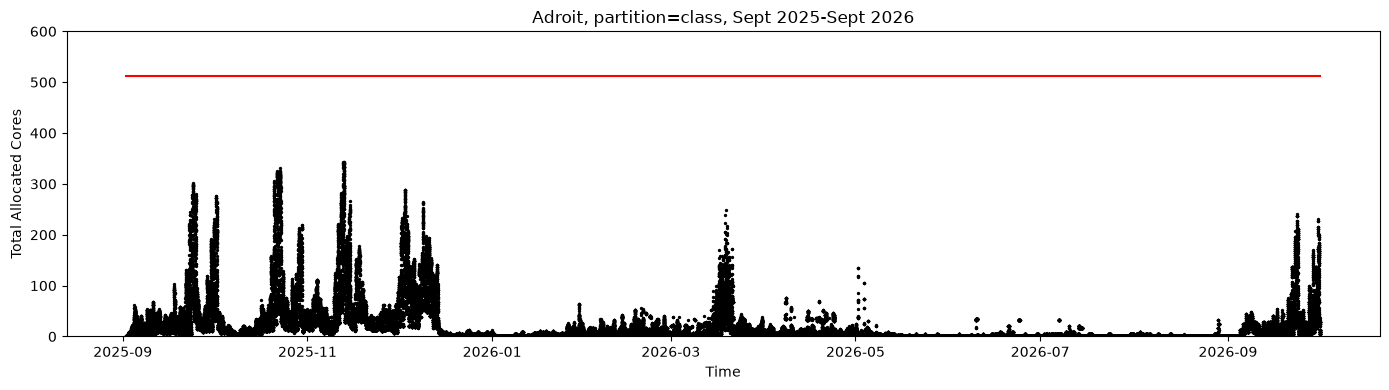

In [12]:
plt.figure(figsize=(14, 4))
dt_pandas = pd.to_datetime(times, unit='s')
plt.scatter(dt_pandas, cores, s=2, c="k")
plt.plot([dt_pandas.min(), dt_pandas.max()], [cores_max, cores_max], c="r")
plt.ylim(0, 600)
plt.xlabel("Time")
plt.ylabel("Total Allocated Cores")
plt.title("Adroit, partition=class, Sept 2025-Sept 2026")
plt.tight_layout()
plt.savefig("adroit_allocated_cores_2025_2026.pdf")
plt.savefig("adroit_allocated_cores_2025_2026.png", dpi=250)